In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Resume/the_wildfire_dataset_2n_version"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

In [ ]:
from PIL import Image
import warnings

Image.MAX_IMAGE_PIXELS = None
warnings.filterwarnings("ignore")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(224,224), batch_size=16, class_mode='categorical')
val_data = val_test_datagen.flow_from_directory(val_dir, target_size=(224,224), batch_size=16, class_mode='categorical')
test_data = val_test_datagen.flow_from_directory(test_dir, target_size=(224,224), batch_size=16, class_mode='categorical', shuffle=False)

class_names = list(train_data.class_indices.keys())

Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(train_data.classes), y=train_data.classes)
class_weights = dict(enumerate(class_weights))

**RESNET50**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [ ]:
history_resnet = resnet_model.fit(train_data, validation_data=val_data, epochs=5, class_weight=class_weights)

# Fine-tune
for layer in base_model.layers[-80:]:
    layer.trainable = True

resnet_model.compile(optimizer=Adam(0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = resnet_model.fit(train_data, validation_data=val_data, epochs=3, class_weight=class_weights)

resnet_test_acc = resnet_model.evaluate(test_data)[1]

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 972s 8s/step - accuracy: 0.6762 - loss: 0.6924 - val_accuracy: 0.8159 - val_loss: 0.3971
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 929s 8s/step - accuracy: 0.7748 - loss: 0.4617 - val_accuracy: 0.8209 - val_loss: 0.4085
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 944s 8s/step - accuracy: 0.8151 - loss: 0.4069 - val_accuracy: 0.8657 - val_loss: 0.3186
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 943s 8s/step - accuracy: 0.8304 - loss: 0.3711 - val_accuracy: 0.8557 - val_loss: 0.3254
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 934s 8s/step - accuracy: 0.8490 - loss: 0.3440 - val_accuracy: 0.8756 - val_loss: 0.3008
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 967s 8s/step - accuracy: 0.8580 - loss: 0.3303 - val_accuracy: 0.8682 - val_loss: 0.3084
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 953s 8s/step - accuracy: 0.8633 - loss: 0.3137 - val_accuracy: 0.8706 - val_loss: 0.3098
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 950s 8s/step - accuracy: 0.8617 - loss: 0.3079 - val_accuracy: 0.

  Efficient NET **B0**

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

eff_model = Model(inputs=base_model.input, outputs=output)

eff_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_eff = eff_model.fit(train_data, validation_data=val_data, epochs=5, class_weight=class_weights)

# Fine-tune
for layer in base_model.layers[-100:]:
    layer.trainable = True

eff_model.compile(optimizer=Adam(0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

history_eff = eff_model.fit(train_data, validation_data=val_data, epochs=3, class_weight=class_weights)

eff_test_acc = eff_model.evaluate(test_data)[1]

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 1792s 15s/step - accuracy: 0.7297 - loss: 0.5190 - val_accuracy: 0.8259 - val_loss: 0.4066
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 743s 6s/step - accuracy: 0.8384 - loss: 0.3855 - val_accuracy: 0.8433 - val_loss: 0.3549
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 731s 6s/step - accuracy: 0.8585 - loss: 0.3377 - val_accuracy: 0.8632 - val_loss: 0.3231
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 749s 6s/step - accuracy: 0.8707 - loss: 0.3135 - val_accuracy: 0.8657 - val_loss: 0.3078
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 741s 6s/step - accuracy: 0.8702 - loss: 0.3111 - val_accuracy: 0.8806 - val_loss: 0.3021
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 850s 7s/step - accuracy: 0.7048 - loss: 0.5247 - val_accuracy: 0.8483 - val_loss: 0.3550
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 789s 7s/step - accuracy: 0.7732 - loss: 0.4509 - val_accuracy: 0.8483 - val_loss: 0.3572
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 799s 7s/step - accuracy: 0.8203 - loss: 0.3974 - val_accuracy: 

Model **Comparison**

In [ ]:
results = {
    "ResNet50": {
        "train": history_resnet.history['accuracy'][-1],
        "val": history_resnet.history['val_accuracy'][-1],
        "test": resnet_test_acc
    },
    "EfficientNetB0": {
        "train": history_eff.history['accuracy'][-1],
        "val": history_eff.history['val_accuracy'][-1],
        "test": eff_test_acc
    }
}

for model, vals in results.items():
    print(f"\n{model}")
    print(vals)


ResNet50
{'train': 0.8616852164268494, 'val': 0.8731343150138855, 'test': 0.9121951460838318}

EfficientNetB0
{'train': 0.8203497529029846, 'val': 0.8432835936546326, 'test': 0.8951219320297241}


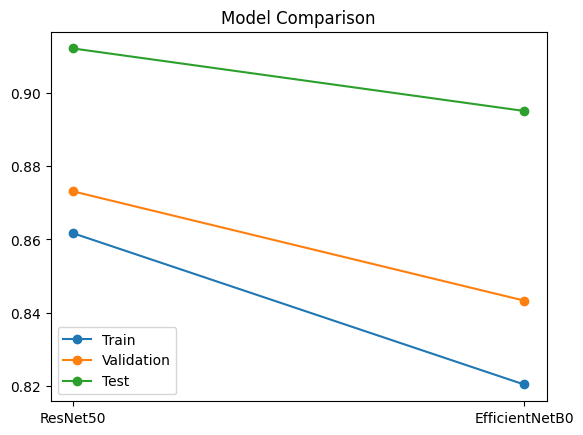

In [ ]:
import matplotlib.pyplot as plt

models = list(results.keys())
train = [results[m]['train'] for m in models]
val = [results[m]['val'] for m in models]
test = [results[m]['test'] for m in models]

plt.plot(models, train, marker='o', label='Train')
plt.plot(models, val, marker='o', label='Validation')
plt.plot(models, test, marker='o', label='Test')
plt.legend()
plt.title("Model Comparison")
plt.show()

Confidence **factor**

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_with_model(model, img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    confidence = np.max(pred)
    label = class_names[np.argmax(pred)]

    return label, confidence

In [ ]:
def risk_alert(pred, conf):
    if pred == "fire" and conf > 0.8:
        return "🔥 HIGH RISK - ALERT!"
    elif pred == "fire":
        return "⚠️ UNCERTAIN FIRE (NO ALERT)"
    else:
        return "✅ SAFE"

Result and Image **Upload**

Saving 8469662796_2ef60dcdb1_o.jpg to 8469662796_2ef60dcdb1_o.jpg


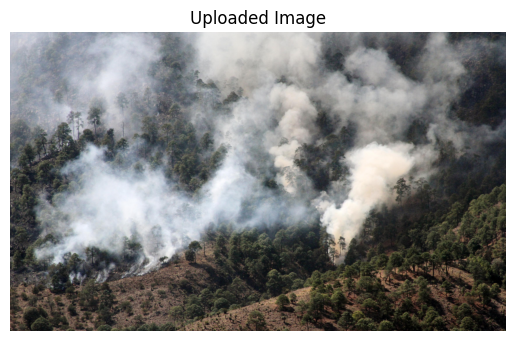

---- ResNet50 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Prediction: fire
Confidence: 0.63
⚠️ UNCERTAIN FIRE (NO ALERT)

---- EfficientNet ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Prediction: fire
Confidence: 0.83
🔥 HIGH RISK - ALERT!


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Display image
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# Predictions
print("---- ResNet50 ----")
pred, conf = predict_with_model(resnet_model, img_path)
print("Prediction:", pred)
print("Confidence:", round(conf,2))
print(risk_alert(pred, conf))

print("\n---- EfficientNet ----")
pred, conf = predict_with_model(eff_model, img_path)
print("Prediction:", pred)
print("Confidence:", round(conf,2))
print(risk_alert(pred, conf))

Saving tautvydas-juknevicius-rYO6kc3mXfo-unsplash.jpg to tautvydas-juknevicius-rYO6kc3mXfo-unsplash.jpg


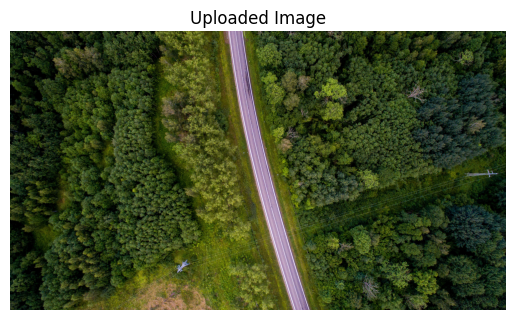

---- ResNet50 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
Prediction: nofire
Confidence: 1.0
✅ SAFE

---- EfficientNet ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Prediction: nofire
Confidence: 0.96
✅ SAFE


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Display image
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# Predictions
print("---- ResNet50 ----")
pred, conf = predict_with_model(resnet_model, img_path)
print("Prediction:", pred)
print("Confidence:", round(conf,2))
print(risk_alert(pred, conf))

print("\n---- EfficientNet ----")
pred, conf = predict_with_model(eff_model, img_path)
print("Prediction:", pred)
print("Confidence:", round(conf,2))
print(risk_alert(pred, conf))

Saving michael-chacon-wRw3L6hwB2E-unsplash.jpg to michael-chacon-wRw3L6hwB2E-unsplash.jpg


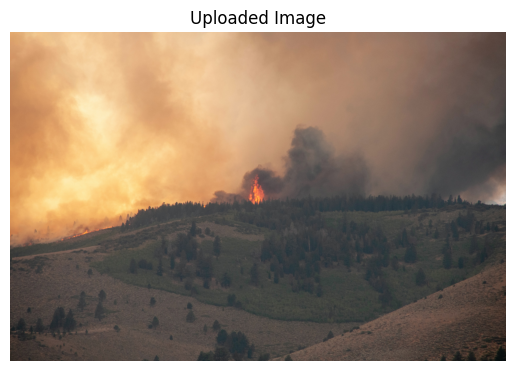

---- ResNet50 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
Prediction: fire
Confidence: 0.83
🔥 HIGH RISK - ALERT!

---- EfficientNet ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Prediction: fire
Confidence: 0.95
🔥 HIGH RISK - ALERT!


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Display image
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# Predictions
print("---- ResNet50 ----")
pred, conf = predict_with_model(resnet_model, img_path)
print("Prediction:", pred)
print("Confidence:", round(conf,2))
print(risk_alert(pred, conf))

print("\n---- EfficientNet ----")
pred, conf = predict_with_model(eff_model, img_path)
print("Prediction:", pred)
print("Confidence:", round(conf,2))
print(risk_alert(pred, conf))